## Competition01 Titanic
### 1. コンペ概要 
Titanic乗客の情報から、生存したかどうかを予測する 

### 2. 目的  
-データ分析の流れを学ぶ  
-前処理を学ぶ  
-初めての機械学習モデルを作成する

### 3. 使用ライブラリ  
-pandas  
-numpy  
-matplotlib  
-scikit-learn

### 4. データ読み込み  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

### 5. EDA(データ確認)

In [6]:
train.head()

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,1,female,35.0,1,0,53.1000,S
1,4,0,3,male,35.0,0,0,8.0500,S
2,7,0,3,male,2.0,3,1,21.0750,S
3,9,1,2,female,14.0,1,0,30.0708,C
4,11,1,1,female,58.0,0,0,26.5500,S


-Survived 生還結果←予測対象  
-pclass 客席のクラス(高級1→3安価)  
-sex 性別  
-age 年齢  
-sibsp 乗船していた兄弟、配偶者の数  
-parch 乗船していた両親、子供の数  
-fare 運賃  
-embarked 乗船した港(S=Southampton, C=Cherbourg, Q=Queenstown)

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        445 non-null    int64  
 1   survived  445 non-null    int64  
 2   pclass    445 non-null    int64  
 3   sex       445 non-null    str    
 4   age       360 non-null    float64
 5   sibsp     445 non-null    int64  
 6   parch     445 non-null    int64  
 7   fare      445 non-null    float64
 8   embarked  443 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 31.4 KB


In [9]:
train.isnull().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
dtype: int64

・445人分のデータがある  
・age(年齢)の欠損85(19%)→補完方法を検討する必要あり  
・embarked(乗船した港)の欠損2→最頻値などで保管できそう  
・文字データはembarked(乗船した港)とsex(性別)→機械学習で扱うため数値へ変換する必要あり

In [11]:
train.describe()

,id,survived,pclass,age,sibsp,parch,fare
count,445.000000,445.000000,445.000000,360.000000,445.000000,445.000000,445.000000
mean,456.002247,0.402247,2.296629,29.211583,0.546067,0.431461,33.959971
std,256.703351,0.490903,0.834024,14.154300,1.195247,0.850489,52.079492
min,3.000000,0.000000,1.000000,0.670000,0.000000,0.000000,0.000000
25%,227.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,463.000000,0.000000,3.000000,28.000000,0.000000,0.000000,15.000000
75%,679.000000,1.000000,3.000000,37.250000,1.000000,1.000000,31.387500
max,888.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


#### 仮説  
①過半数以上が3ということから、1等客室より3等客室の方が生存率が高そうだと予想できる  
②優先的に避難できていたため女性の方が生存率が高そう  
③子供と大人で生存率の違いはありそう  
④運賃高い方が生存率高そう

#### 仮説の検証

##### ①客室pclass(重要)

In [12]:
train.groupby("pclass")["survived"].mean()

pclass
1    0.685185
2    0.443299
3    0.258333
Name: survived, dtype: float64

高級であるほど生存率が高い傾向にある

##### ②性別sex(最重要)

In [10]:
train.groupby("sex")["survived"].mean()

sex
female    0.775641
male      0.200692
Name: survived, dtype: float64

女性の方がかなり生存率が高い

##### ③年齢age

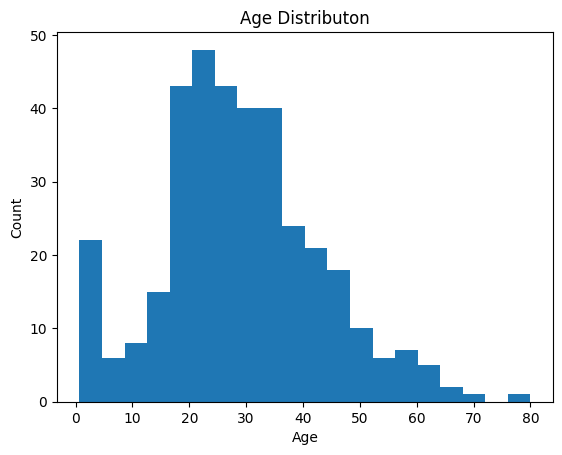

In [18]:
train["age"].plot(kind="hist", bins= 20)
plt.title("Age Distributon")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

kind...グラフの種類  
bins...20本に分布する

年齢の分布は若い方によっていて、20代や30代が多い。また0~5歳くらいの小さい子どもも少し多く20人以上いる。高齢者(50代以降)はかなり少ない。中央値で補完するのはいい気がするが中央が増えすぎてしまうため、一回中央値で補完したのち方法を考える

##### ④運賃fare

In [14]:
train.groupby("survived")["fare"].mean()

survived
0    22.924262
1    50.359405
Name: fare, dtype: float64

生存者の方が運賃が高い傾向にはあるが最大値が512だったり第三四分位数が30ぐらいなので外れ値の影響も考えられるそのため平均だけでは断定できないので分布をみる

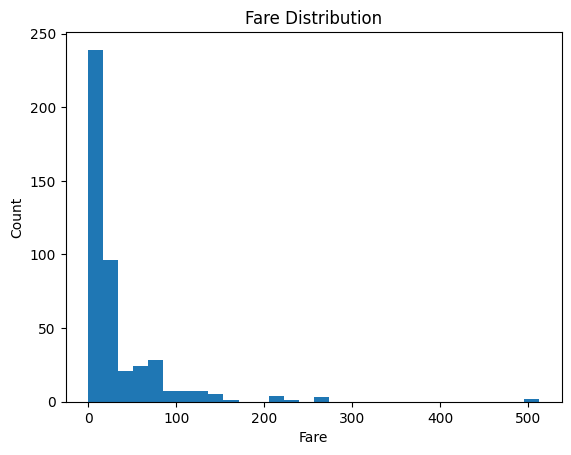

In [19]:
train["fare"].plot(kind="hist", bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

最大値である512は外れ値で0~100にほとんどの人がいる。かなり偏りがあることがわかる。運賃と生存率の関係をさらに分析する

In [20]:
train.groupby("survived")["fare"].describe()

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,266.0,22.924262,30.913610,0.000,7.8542,10.5,26.0000,263.0000
1,179.0,50.359405,69.930383,6.975,12.7375,26.0,61.4896,512.3292


In [22]:
train["fare_100"] = np.where(train["fare"] >= 100,"High", "Low")
train.groupby("fare_100")["survived"].mean()

fare_100
High    0.733333
Low     0.378313
Name: survived, dtype: float64

運賃が100超えてる人高い人の方がかなり生存率が高いことが分かった

In [24]:
train.groupby("fare_100")["pclass"].describe()

,count,mean,std,min,25%,50%,75%,max
fare_100,,,,,,,,
High,30.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Low,415.0,2.390361,0.784453,1.0,2.0,3.0,3.0,3.0


運賃が100以上の人は全員1等客室、運賃と客室には相関関係がある

##### ⑤乗船した港embarked

In [15]:
train.groupby("embarked")["survived"].mean()

embarked
C    0.594937
Q    0.410256
S    0.350769
Name: survived, dtype: float64

Cから乗船した人生存率高い。Embarkedは生存率に影響している可能性があるが、Pclassなど他の特徴量との関係も考慮して分析する必要がある

### 6. 前処理

### 7. 特徴量作成

### 8. モデル作成

### 9. 提出

### 10. 結果

### 11. 改善点

### 12. 学んだこと